In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PyQt6.QtWidgets.QWidget import lower
from debugpy.adapter.components import missing
from matplotlib import rcParams
rcParams["font.sans-serif"] = ["SimHei"]  # 指定中文字体

# 读取 CSV 文件
data = pd.read_csv('data/house_sales.csv')
print('数据基本信息：')
data.info()

数据基本信息：
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             10000 non-null  int64  
 1   date           10000 non-null  str    
 2   price          10000 non-null  float64
 3   bedrooms       10000 non-null  int64  
 4   bathrooms      10000 non-null  int64  
 5   sqft_living    10000 non-null  int64  
 6   sqft_lot       10000 non-null  int64  
 7   floors         10000 non-null  int64  
 8   waterfront     10000 non-null  int64  
 9   view           10000 non-null  int64  
 10  condition      10000 non-null  int64  
 11  grade          10000 non-null  int64  
 12  sqft_above     10000 non-null  int64  
 13  sqft_basement  10000 non-null  int64  
 14  yr_built       10000 non-null  int64  
 15  yr_renovated   10000 non-null  int64  
 16  zipcode        10000 non-null  int64  
 17  lat            10000 non-null  float64
 18  long      

In [5]:
# 数据清清洗
missing_values = data.isnull().sum()
print('缺失值统计：')
print(missing_values)

data = data.dropna()

Q1 = data['price'].quantile(0.25)
Q3 = data['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
data = data[(data['price'] >= lower_bound) & (data['price'] <= upper_bound)]

缺失值统计：
id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
dtype: int64


In [13]:
data['data'] = pd.to_datetime(data['date'])
data['age'] = data['data'].dt.year - data['yr_built']
data['is_renovated'] = data['yr_renovated'].apply(lambda x: 1 if x > 0 else 0)

In [17]:
# 选择数值型列
numeric_columns = data.select_dtypes(include=np.number).columns
description = data[numeric_columns].describe()
print(description)

                 id          price     bedrooms    bathrooms  sqft_living  \
count   9930.000000    9930.000000  9930.000000  9930.000000  9930.000000   
mean    5001.107049  501121.772151     4.496878     3.521349  2906.238671   
std     2885.966447   97124.951211     2.297853     1.727304  1210.034706   
min        1.000000  229983.900000     1.000000     1.000000   801.000000   
25%     2503.250000  433529.705000     2.000000     2.000000  1865.000000   
50%     5001.500000  501561.090000     4.000000     4.000000  2909.000000   
75%     7496.750000  567653.252500     7.000000     5.000000  3957.000000   
max    10000.000000  770223.220000     8.000000     6.000000  5000.000000   

           sqft_lot       floors   waterfront         view    condition  \
count   9930.000000  9930.000000  9930.000000  9930.000000  9930.000000   
mean    5520.495065     1.999295     0.498489     2.016314     2.985901   
std     2604.054446     0.819431     0.500023     1.418670     1.416136   
min   

In [18]:
correlation_matrix = data[numeric_columns].corr()
print('各特征与房价的相关性')
print(correlation_matrix['price'])

各特征与房价的相关性
id               0.011216
price            1.000000
bedrooms         0.004881
bathrooms        0.008096
sqft_living      0.011616
sqft_lot         0.003644
floors          -0.005926
waterfront       0.001748
view            -0.002817
condition        0.001813
grade            0.004603
sqft_above      -0.005068
sqft_basement   -0.003476
yr_built         0.012998
yr_renovated    -0.000186
zipcode          0.007931
lat             -0.001472
long            -0.006436
age             -0.004177
is_renovated    -0.000069
Name: price, dtype: float64


In [21]:
zipcode_stats = data.groupby('zipcode').agg({
    'price': ['mean'],
    'sqft_living': ['mean'],
    'bedrooms': ['mean']
})
zipcode_stats.columns = ['avg_price', 'avg_sqft_living', 'avg_bedrooms']
print(zipcode_stats)

             avg_price  avg_sqft_living  avg_bedrooms
zipcode                                              
98001    502211.909176      2917.520854      4.357905
98002    497808.793483      2955.262821      4.554487
98003    497930.512592      2870.403689      4.547131
98004    498747.163954      2857.314854      4.407950
98005    503306.661532      2975.695481      4.548134
98006    505345.428558      2887.992944      4.599798
98007    502716.775391      2900.131553      4.358061
98008    499171.818208      2877.518519      4.499499
98009    500330.593340      2901.382627      4.472596
98010    503083.699933      2916.949234      4.623563


In [24]:
data['age_group'] = pd.cut(data['age'], bins=5)
age_stats = data.groupby('age_group').agg({
    'price': ['mean'],
    'sqft_living': ['mean'],
    'bedrooms': ['mean']
})
age_stats.columns = ['avg_price', 'avg_sqft_living', 'avg_bedrooms']
print(age_stats)

                    avg_price  avg_sqft_living  avg_bedrooms
age_group                                                   
(-0.124, 24.8]  501594.625623      2912.909214      4.511300
(24.8, 49.6]    500933.820999      2912.564145      4.485583
(49.6, 74.4]    501518.890152      2867.016575      4.421271
(74.4, 99.2]    496723.141722      2910.078910      4.628407
(99.2, 124.0]   503413.042977      2926.920930      4.358140


In [26]:
year_avg_price = data.groupby('yr_built')['price'].mean()
print(year_avg_price)

yr_built
1900    491780.476164
1901    481128.883636
1902    502031.394607
1903    489723.853721
1904    507066.146515
            ...      
2020    523832.699744
2021    507616.162195
2022    491350.920230
2023    477222.434348
2024    502557.267536
Name: price, Length: 125, dtype: float64


In [27]:
yearly_renovation_avg_price = data.groupby('yr_renovated')['price'].mean()
print(yearly_renovation_avg_price)

yr_renovated
0       501126.095841
1903    616253.490000
1904    478779.410000
1905    500612.416667
1906    550730.285000
            ...      
2020    519027.210000
2021    507096.190476
2022    489801.561158
2023    497195.526970
2024    521547.828478
Name: price, Length: 122, dtype: float64


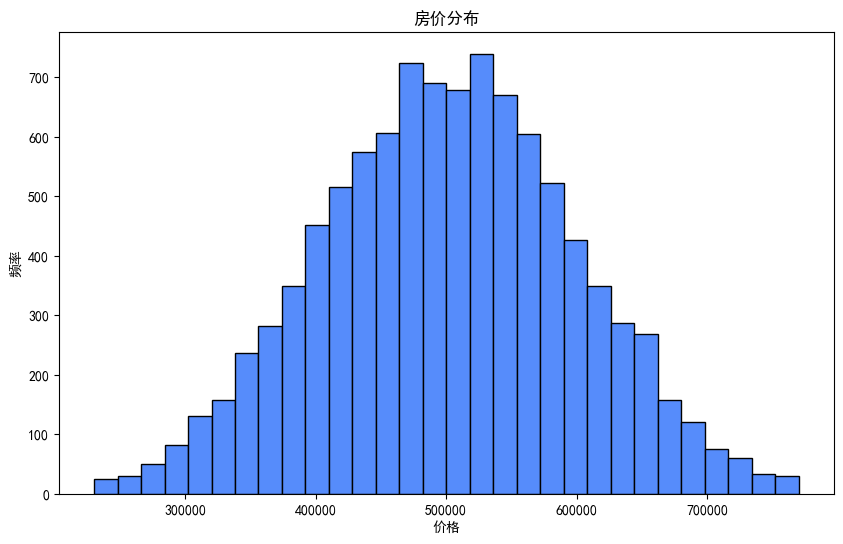

In [28]:
plt.figure(figsize=(10, 6))
plt.hist(data['price'], bins=30, edgecolor='k')
plt.xlabel('价格')
plt.ylabel('频率')
plt.title('房价分布')
plt.show()

